**Aim:**

Building a Simple Data Science Pipeline by integrating data preprocessing, EDA, feature engineering, and modeling into a complete workflow.

Theory
1. What is a Data Science Pipeline?

A Data Science pipeline is a structured sequence of steps used to collect, process, analyze, and model data to extract meaningful insights or make predictions. It ensures that the workflow is systematic, reproducible, and efficient. The key stages include data collection (gathering raw data from sources like databases or CSV files), data cleaning (handling missing values and errors), exploratory data analysis (understanding patterns and relationships), feature engineering (creating useful input variables), model building (training machine learning models), evaluation (checking accuracy), and deployment (using the model in real-world applications). For example, in a house price prediction system, data is collected from property listings, cleaned by removing missing values, analyzed for trends, features like price per square foot are created, and a regression model is trained to predict prices.

2. What is Exploratory Data Analysis (EDA)?

Exploratory Data Analysis (EDA) is the process of analyzing and summarizing datasets using statistical and visualization techniques to understand their structure, patterns, and relationships. It helps in detecting anomalies, checking assumptions, and preparing data for modeling. Univariate analysis focuses on a single variable to understand its distribution, central tendency, and spread using histograms or boxplots. For example, analyzing the distribution of house prices. Bivariate analysis examines relationships between two variables, such as correlation between area and price using scatter plots or correlation matrices. Together, these analyses help identify important features, detect outliers, and guide further preprocessing steps.

3. Label Encoding vs One-Hot Encoding

Label Encoding and One-Hot Encoding are techniques used to convert categorical data into numerical form for machine learning models. Label Encoding assigns a unique integer to each category (e.g., Red=0, Blue=1, Green=2), which is useful when the categories have an inherent order, such as low, medium, and high. However, it can mislead models into assuming a numerical relationship between categories. One-Hot Encoding creates separate binary columns for each category (e.g., Red=[1,0,0], Blue=[0,1,0]), ensuring no ordinal relationship is implied. It is preferred when categories are nominal (no order), such as colors or city names. Therefore, Label Encoding is suitable for ordinal data, while One-Hot Encoding is better for nominal data.

4. Why is Feature Scaling Required?

Feature scaling is necessary because machine learning algorithms are sensitive to the scale of input features. If one feature has a larger range than others, it can dominate the model and affect performance. Scaling ensures that all features contribute equally. Normalization (Min-Max Scaling) transforms values to a range between 0 and 1 using the minimum and maximum values, making it useful when data does not follow a normal distribution. Standardization (Z-score normalization) transforms data to have a mean of 0 and standard deviation of 1, making it suitable for algorithms like linear regression and logistic regression that assume normally distributed data. Choosing between them depends on the dataset and algorithm used.

5. What is Feature Engineering?

Feature engineering is the process of creating new input features from existing data to improve the performance of machine learning models. It involves transforming raw data into meaningful variables that better represent the underlying patterns. For example, in a house price dataset, instead of using only total price and area, a new feature like price per square foot can be created. Similarly, extracting year, month, or day from date features can provide additional insights. Good feature engineering can significantly enhance model accuracy by making patterns more visible and improving the model’s ability to learn relationships.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Load Dataset

In [ ]:
# Sample dataset (you can replace with your own CSV)
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Basic Info

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Check Missing Values

In [ ]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


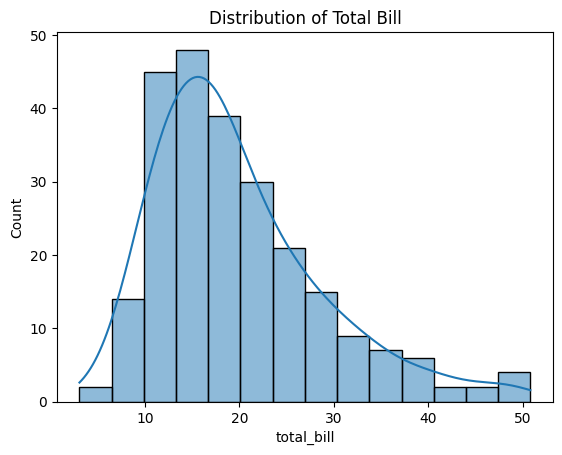

In [ ]:
sns.histplot(df['total_bill'], kde=True)
plt.title("Distribution of Total Bill")
plt.show()

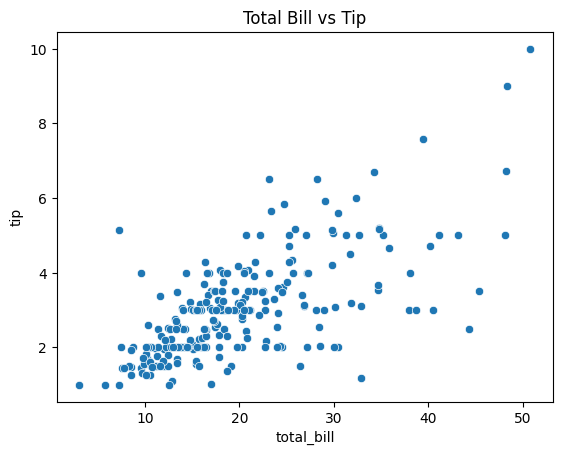

In [ ]:
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title("Total Bill vs Tip")
plt.show()

In [ ]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,No,Sun,Dinner,2
1,10.34,1.66,1,No,Sun,Dinner,3
2,21.01,3.50,1,No,Sun,Dinner,3
3,23.68,3.31,1,No,Sun,Dinner,2
4,24.59,3.61,0,No,Sun,Dinner,4


In [ ]:
df = pd.get_dummies(df, columns=['day'], drop_first=True)
df.head()

,total_bill,tip,sex,smoker,time,size,day_Sat,day_Sun,day_Thur
0,16.99,1.01,0,No,Dinner,2,False,True,False
1,10.34,1.66,1,No,Dinner,3,False,True,False
2,21.01,3.50,1,No,Dinner,3,False,True,False
3,23.68,3.31,1,No,Dinner,2,False,True,False
4,24.59,3.61,0,No,Dinner,4,False,True,False


In [ ]:
# Create new feature
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100
df.head()

,total_bill,tip,sex,smoker,time,size,day_Sat,day_Sun,day_Thur,tip_percentage
0,16.99,1.01,0,No,Dinner,2,False,True,False,5.944673
1,10.34,1.66,1,No,Dinner,3,False,True,False,16.054159
2,21.01,3.50,1,No,Dinner,3,False,True,False,16.658734
3,23.68,3.31,1,No,Dinner,2,False,True,False,13.978041
4,24.59,3.61,0,No,Dinner,4,False,True,False,14.680765


In [ ]:
scaler = StandardScaler()
df[['total_bill', 'tip']] = scaler.fit_transform(df[['total_bill', 'tip']])

df.head()

,total_bill,tip,sex,smoker,time,size,day_Sat,day_Sun,day_Thur,tip_percentage
0,-0.314711,-1.439947,0,No,Dinner,2,False,True,False,5.944673
1,-1.063235,-0.969205,1,No,Dinner,3,False,True,False,16.054159
2,0.137780,0.363356,1,No,Dinner,3,False,True,False,16.658734
3,0.438315,0.225754,1,No,Dinner,2,False,True,False,13.978041
4,0.540745,0.443020,0,No,Dinner,4,False,True,False,14.680765


In [ ]:
X = df.drop('tip', axis=1)
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
# To fix the error, we need to one-hot encode the remaining categorical columns ('smoker' and 'time')
df_encoded = pd.get_dummies(df, columns=['smoker', 'time'], drop_first=True, dtype=int)

X = df_encoded.drop('tip', axis=1)
y = df_encoded['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.1272685268697003


**Conclusion**

In this assignment, a complete data science pipeline was implemented starting from data loading and cleaning to EDA, feature encoding, scaling, and model building. Each step plays a crucial role in improving data quality and model performance. By integrating all these stages, we can build efficient and reliable machine learning systems.